<a href="https://colab.research.google.com/github/Gabriel-idkw/Customer-Behavior-Prediction/blob/main/03_hierarchical_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Agglomerative Hierarchical Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, itertools, time
import joblib
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RANDOM_STATE = 42
FORCED_K = 4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load Baseline

In [3]:
df_full = pd.read_csv('/content/drive/MyDrive/project/data/preprocessed_rfm_scaled.csv')
feature_cols = ['Recency_scaled', 'Frequency_log_scaled', 'Monetary_log_scaled', 'AOV_scaled', 'Return_Rate_Pct_scaled']
print(f"Full baseline: {df_full.shape[0]:,} customers x {len(feature_cols)} features")

SAMPLE_SIZE = 10000
df = df_full.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
X = df[feature_cols].values
print(f"Working sample for hierarchical clustering: {X.shape[0]:,} customers")

Full baseline: 49,661 customers x 5 features
Working sample for hierarchical clustering: 10,000 customers


## 2. Grid Search Implementation
Parameter grid across:
- **Cluster Count (K):** 2 - 8
- **Linkage Criteria:** ward, complete, average
- **Distance Metrics:** euclidean, manhattan

In [4]:
param_combos = []
for k in range(2, 9):
    for linkage_type in ['ward', 'complete', 'average']:
        metrics_to_try = ['euclidean'] if linkage_type == 'ward' else ['euclidean', 'manhattan']
        for metric in metrics_to_try:
            param_combos.append({'k': k, 'linkage': linkage_type, 'metric': metric})

print(f"Total grid combinations: {len(param_combos)}")

results = []
start = time.time()
for params in param_combos:
    model = AgglomerativeClustering(n_clusters=params['k'], linkage=params['linkage'], metric=params['metric'])
    labels = model.fit_predict(X)
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    results.append({**params, 'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch})

results_df = pd.DataFrame(results)
print(f"Grid search complete: {len(results_df)} combinations in {time.time()-start:.1f}s")
results_df.sort_values('silhouette', ascending=False).head(10)


Total grid combinations: 35
Grid search complete: 35 combinations in 318.6s


,k,linkage,metric,silhouette,davies_bouldin,calinski_harabasz
3,2,average,euclidean,0.410574,0.680885,404.309860
8,3,average,euclidean,0.376121,0.915403,654.962480
4,2,average,manhattan,0.362873,1.419149,3130.996020
2,2,complete,manhattan,0.346487,1.557280,2301.080721
9,3,average,manhattan,0.341578,1.528566,1863.127342
7,3,complete,manhattan,0.323413,1.409858,1540.474542
1,2,complete,euclidean,0.304166,1.606872,2355.343902
14,4,average,manhattan,0.301637,1.621866,1469.239443
13,4,average,euclidean,0.301447,1.137738,1032.714718
18,5,average,euclidean,0.295361,1.093978,812.733722


## 3. Record Evaluation Metrics

In [5]:
search_pool = results_df[results_df['k'] == FORCED_K] if FORCED_K is not None else results_df
if FORCED_K is not None:
    print(f"FORCED_K={FORCED_K}: selecting the best hyperparameters among the {len(search_pool)} "
          f"grid combinations run at K={FORCED_K} (out of {len(results_df)} total).")

best_row = search_pool.sort_values('silhouette', ascending=False).iloc[0]
best_k = int(best_row['k'])
best_linkage = best_row['linkage']
best_metric = best_row['metric']

print("Best hyperparameters (by Silhouette Score):")
print(f"  K = {best_k}, linkage = {best_linkage}, metric = {best_metric}")
print(f"  Silhouette Score:        {best_row['silhouette']:.4f}")
print(f"  Davies-Bouldin Index:    {best_row['davies_bouldin']:.4f}")
print(f"  Calinski-Harabasz Index: {best_row['calinski_harabasz']:.1f}")


FORCED_K=4: selecting the best hyperparameters among the 5 grid combinations run at K=4 (out of 35 total).
Best hyperparameters (by Silhouette Score):
  K = 4, linkage = average, metric = manhattan
  Silhouette Score:        0.3016
  Davies-Bouldin Index:    1.6219
  Calinski-Harabasz Index: 1469.2


In [6]:
best_model = AgglomerativeClustering(n_clusters=best_k, linkage=best_linkage, metric=best_metric)
cluster_labels = best_model.fit_predict(X)
df['cluster'] = cluster_labels
df['cluster'].value_counts().sort_index()


,count
cluster,
0,1045
1,8326
2,251
3,378


## 4. Generate Visualizations
### Dendrogram Tree Diagram

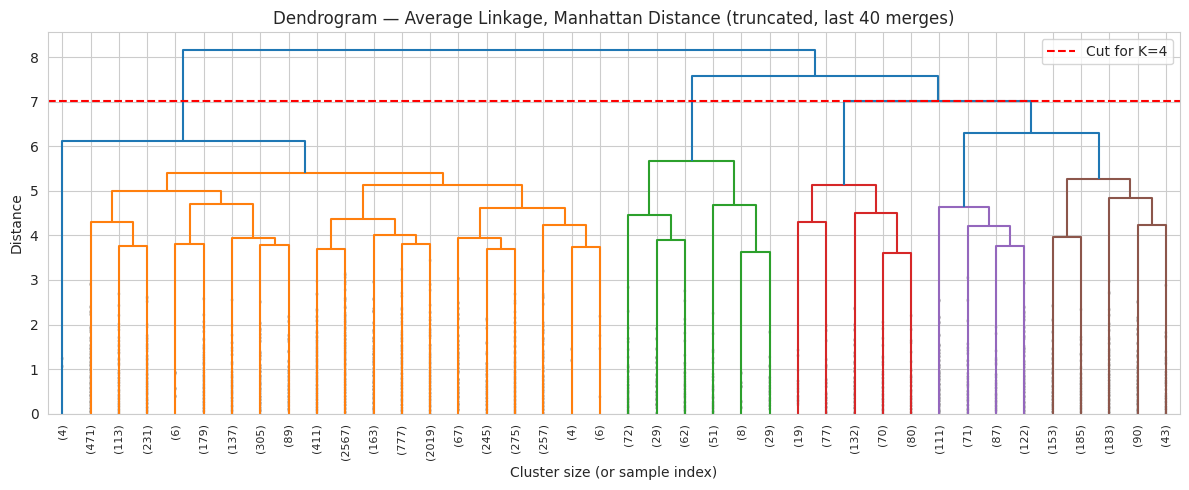

In [8]:
Z = scipy_linkage(X,
                  method=best_linkage if best_linkage != 'ward' or best_metric == 'euclidean' else 'average',
                  metric='euclidean' if best_linkage == 'ward' else ('cityblock' if best_metric == 'manhattan' else best_metric))

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=40, leaf_rotation=90, leaf_font_size=8, show_contracted=True)
plt.axhline(y=Z[-(best_k-1), 2], color='red', linestyle='--', label=f'Cut for K={best_k}')
plt.title(f'Dendrogram — {best_linkage.title()} Linkage, {best_metric.title()} Distance (truncated, last 40 merges)')
plt.xlabel('Cluster size (or sample index)')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/project/data/hierarchical_dendrogram.png', dpi=110)
plt.show()

### Linkage Comparison Bar Chart

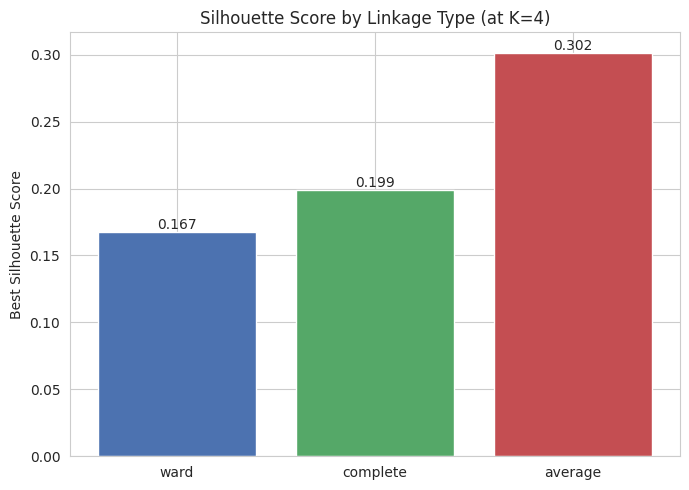

In [9]:
linkage_compare = (results_df[results_df['k'] == best_k]
                    .groupby('linkage')['silhouette'].max().reindex(['ward', 'complete', 'average']))

plt.figure(figsize=(7, 5))
bars = plt.bar(linkage_compare.index, linkage_compare.values, color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylabel('Best Silhouette Score')
plt.title(f'Silhouette Score by Linkage Type (at K={best_k})')
for bar, val in zip(bars, linkage_compare.values):
    plt.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/project/data/hierarchical_linkage_comparison.png', dpi=110)
plt.show()


### 2D PCA Scatter Plot

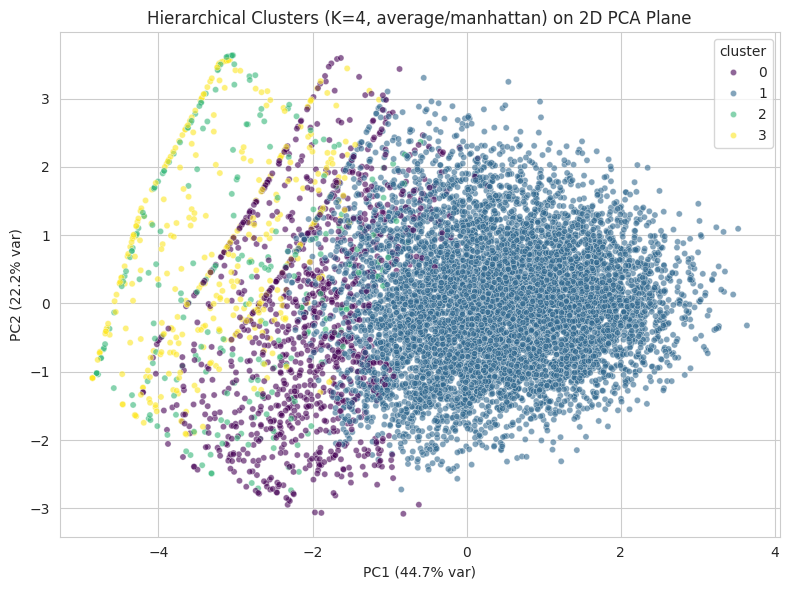

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X)
df['PC1'], df['PC2'] = pcs[:, 0], pcs[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='cluster', palette='viridis', alpha=0.6, s=20, legend='full')
plt.title(f'Hierarchical Clusters (K={best_k}, {best_linkage}/{best_metric}) on 2D PCA Plane')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/project/data/hierarchical_pca_scatter.png', dpi=110)
plt.show()


## 5. Export Artifacts

In [11]:
joblib.dump(best_model, '/content/drive/MyDrive/project/models/hierarchical_model.pkl')

hierarchical_results = {
    'algorithm': 'AgglomerativeClustering',
    'assigned_member': 'Student 2',
    'sample_size_used': SAMPLE_SIZE,
    'sample_note': 'Fit on a random 4,000-customer sample due to O(n^2) memory/time cost at full scale (~49.7k customers).',
    'grid_search_space': {'k': list(range(2, 9)), 'linkage': ['ward', 'complete', 'average'], 'metric': ['euclidean', 'manhattan']},
    'best_params': {'k': best_k, 'linkage': best_linkage, 'metric': best_metric},
    'best_metrics': {
        'silhouette_score': float(best_row['silhouette']),
        'davies_bouldin_index': float(best_row['davies_bouldin']),
        'calinski_harabasz_index': float(best_row['calinski_harabasz']),
    },
    'all_grid_results': results_df.to_dict(orient='records'),
    'cluster_sizes': df['cluster'].value_counts().sort_index().to_dict(),
}

with open('/content/drive/MyDrive/project/metrics/hierarchical_results.json', 'w') as f:
    json.dump(hierarchical_results, f, indent=2, default=str)

print("Saved /content/drive/MyDrive/project/models/hierarchical_model.pkl and /content/drive/MyDrive/project/metrics/hierarchical_results.json")


Saved /content/drive/MyDrive/project/models/hierarchical_model.pkl and /content/drive/MyDrive/project/metrics/hierarchical_results.json
